<a href="https://colab.research.google.com/github/SHRESHTH121/HandsOnMachineLearning/blob/main/PrincipalComponentUsingSVD.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import numpy as np
from scipy.spatial.transform import Rotation

m = 60
X = np.zeros((m, 3))  # initialize 3D dataset
np.random.seed(42)
angles = (np.random.rand(m) ** 3 + 0.5) * 2 * np.pi  # uneven distribution
X[:, 0], X[:, 1] = np.cos(angles), np.sin(angles) * 0.5  # oval
X += 0.28 * np.random.randn(m, 3)  # add more noise
X = Rotation.from_rotvec([np.pi / 29, -np.pi / 20, np.pi / 4]).apply(X)
X += [0.2, 0, 0.2]  # shift a bit

# **Finding Principal Components**

In [2]:
X_centered = X - X.mean(axis=0)
U, s, Vt = np.linalg.svd(X_centered)
c1 = Vt[0]
c2 = Vt[1]

In [3]:
c1

array([0.67857588, 0.70073508, 0.22023881])

In [4]:
c2

array([-0.72817329,  0.6811147 ,  0.07646185])

# **Making a hyper plane using first 2 PC's**

In [5]:
W2 = Vt[:2].T
X2D = X_centered @ W2

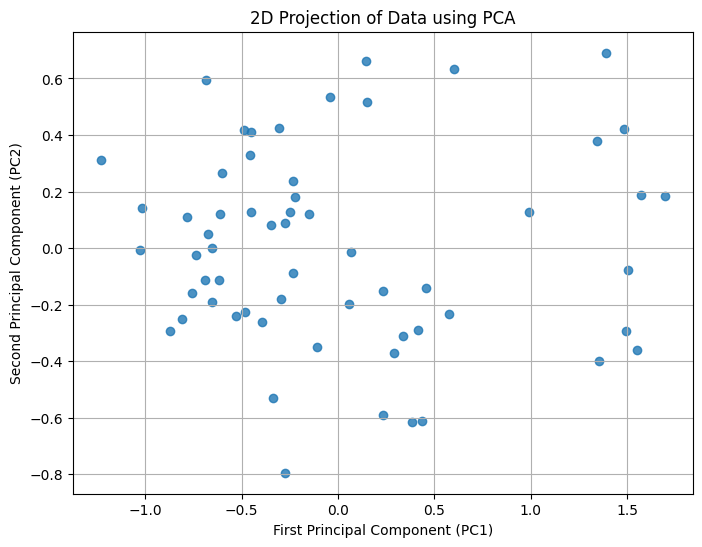

In [9]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 6))
plt.scatter(X2D[:, 0], X2D[:, 1], alpha=0.8)
plt.xlabel('First Principal Component (PC1)')
plt.ylabel('Second Principal Component (PC2)')
plt.title('2D Projection of Data using PCA')
plt.grid(True)
plt.show()

all the above steps can be done using sklearn

In [21]:
from sklearn.decomposition import PCA

pca = PCA(n_components=2)  #If you set the svd_solver hyperparameter to "randomized", Scikit-Learn uses a
#stochastic algorithm called Randomized PCA that quickly finds an approximation of the first d principal components.
#it is dramatically faster than full SVD when d is much smaller than n
X2D = pca.fit_transform(X)

In [12]:
pca.components_   #its transpose holds unit vectors

array([[ 0.67857588,  0.70073508,  0.22023881],
       [ 0.72817329, -0.6811147 , -0.07646185]])

Explained varience ratio tells us how much of total variance does each PC hold

In [13]:
pca.explained_variance_ratio_

array([0.7578477 , 0.15186921])

The first dimension explains about 76% of the variance, while the second explains about 15%.

By projecting down to 2D, we lost about 9% of the variance:

# **Finding right number of components**

In [18]:
pca=PCA(n_components=0.90)

In [19]:
X2D=pca.fit_transform(X)

In [20]:
pca.n_components_

np.int64(2)